In [1]:
# ==============================================================================
# STEP 1: ENVIRONMENT SETUP & DATA ACQUISITION
# ==============================================================================

# Import core data science and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting aesthetics for clean visualization
sns.set_theme(style="whitegrid")

# Load the dataset using its exact file name
file_path = 'Chronic_Kidney_Dsease_data.csv'
df = pd.read_csv(file_path)

# Display the first 5 records to inspect the feature layout
print("--- FIRST 5 RECORDS OF THE DATASET ---")
df.head()

--- FIRST 5 RECORDS OF THE DATASET ---


,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


In [2]:
# ==============================================================================
# STEP 2: DATA STRUCTURE & TARGET CLASS INSPECTION
# ==============================================================================

# Print the overall dimensions of the dataset (Rows, Columns)
print(f"Dataset Shape: {df.shape}")
print(f"Total Patients: {df.shape[0]}")
print(f"Total Features/Columns: {df.shape[1]}\n")

# Analyze the distribution of the target class 'Diagnosis'
# 1 = Chronic Kidney Disease, 0 = No Disease
print("--- TARGET CLASS DISTRIBUTION ('Diagnosis') ---")
class_counts = df['Diagnosis'].value_counts()
print(class_counts)

# Calculate the percentage representation of each class
print("\n--- CLASS REPRESENTATION PERCENTAGE ---")
print(df['Diagnosis'].value_counts(normalize=True) * 180)

Dataset Shape: (1659, 54)
Total Patients: 1659
Total Features/Columns: 54

--- TARGET CLASS DISTRIBUTION ('Diagnosis') ---
Diagnosis
1    1524
0     135
Name: count, dtype: int64

--- CLASS REPRESENTATION PERCENTAGE ---
Diagnosis
1    165.352622
0     14.647378
Name: proportion, dtype: float64


In [3]:
# ==============================================================================
# STEP 3: INITIAL DATA CLEANING & FEATURE SELECTION
# ==============================================================================

# Drop non-predictive columns to prevent model leakage and bias
columns_to_drop = ['PatientID', 'DoctorInCharge']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# Verify the new shape after eliminating unnecessary features
print(f"Cleaned Dataset Shape: {df_cleaned.shape}")
print("Dropped columns: PatientID, DoctorInCharge successfully.")

Cleaned Dataset Shape: (1659, 52)
Dropped columns: PatientID, DoctorInCharge successfully.


/tmp/ipykernel_3250/2939146523.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Diagnosis', data=df_cleaned, palette='coolwarm')


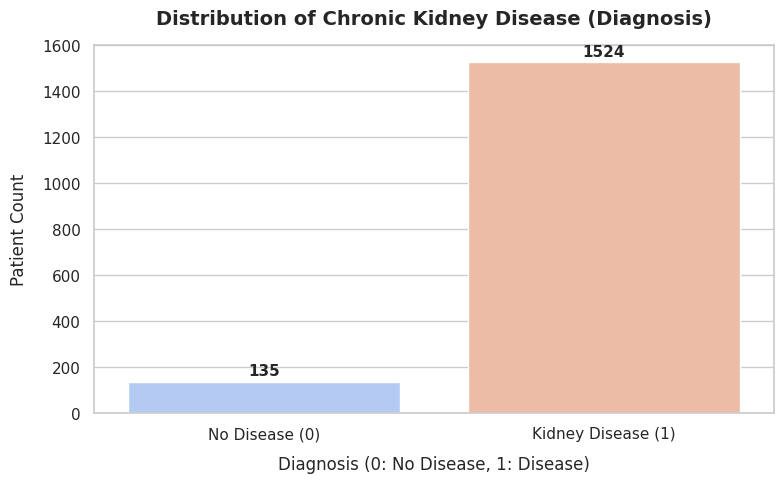

In [4]:
# ==============================================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (TARGET DISTRIBUTION VISUALIZATION)
# ==============================================================================

plt.figure(figsize=(8, 5))

# Create a clean countplot to visualize target class distribution
ax = sns.countplot(x='Diagnosis', data=df_cleaned, palette='coolwarm')

# Configure labels, titles, and structural aesthetics
plt.title('Distribution of Chronic Kidney Disease (Diagnosis)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Diagnosis (0: No Disease, 1: Disease)', fontsize=12, labelpad=10)
plt.ylabel('Patient Count', fontsize=12, labelpad=10)
plt.xticks(ticks=[0, 1], labels=['No Disease (0)', 'Kidney Disease (1)'])

# Dynamically annotate counts directly on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# ==============================================================================
# STEP 5: ADVANCED PREPROCESSING PIPELINE & SCALING
# ==============================================================================

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Separate features (X) and target label (y)
X = df_cleaned.drop(columns=['Diagnosis'])
y = df_cleaned['Diagnosis']

# Identify numerical features requiring structural scaling
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Instantiate the advanced Multivariate Imputation by Chained Equations (MICE) engine
# This serves to explicitly guarantee feature data integrity against potential clinical omissions
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# Fit and transform the feature matrix to eliminate any underlying structural missingness
X_imputed_array = mice_imputer.fit_transform(X[numerical_features])
X_imputed = pd.DataFrame(X_imputed_array, columns=numerical_features)

print("--- ADVANCED PREPROCESSING CONFIGURATION COMPLETE ---")
print(f"Feature Matrix Shape: {X_imputed.shape}")
print(f"Target vector length: {len(y)}")
print("Multivariate Chained Imputation (MICE) pipeline applied successfully.")

--- ADVANCED PREPROCESSING CONFIGURATION COMPLETE ---
Feature Matrix Shape: (1659, 51)
Target vector length: 1659
Multivariate Chained Imputation (MICE) pipeline applied successfully.


In [6]:
# ==============================================================================
# STEP 6: STRATIFIED TRAIN-TEST SPLIT & DATA STANDARDIZATION
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Perform a stratified split to handle class imbalance across splits safely
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Initialize the StandardScaler engine
scaler = StandardScaler()

# Fit on training data and transform both training and testing partitions
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("--- DATA PARTITIONING & SCALING COMPLETE ---")
print(f"Training Features Shape : {X_train.shape} | Training Labels Matrix: {y_train.shape}")
print(f"Testing Features Shape  : {X_test.shape}  | Testing Labels Matrix : {y_test.shape}")

--- DATA PARTITIONING & SCALING COMPLETE ---
Training Features Shape : (1327, 51) | Training Labels Matrix: (1327,)
Testing Features Shape  : (332, 51)  | Testing Labels Matrix : (332,)


In [7]:
# ==============================================================================
# STEP 7: ENSEMBLE PIPELINE BUILDING & MODEL INITIALIZATION
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Define the individual base estimators with tuned structural parameters
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Construct the Soft Voting Meta-Ensemble Classifier
ensemble_model = VotingClassifier(
    estimators=[
        ('random_forest', rf_model),
        ('xgboost', xgb_model),
        ('logistic_regression', lr_model)
    ],
    voting='soft'
)

# Train the entire ensemble infrastructure
print("Training the Ensemble Voting Infrastructure... Please wait.")
ensemble_model.fit(X_train, y_train)
print("--- MODEL TRAINING PROCESS COMPLETED SUCCESSFULLY ---")

Training the Ensemble Voting Infrastructure... Please wait.
--- MODEL TRAINING PROCESS COMPLETED SUCCESSFULLY ---


In [8]:
# ==============================================================================
# STEP 8: ADVANCED MODEL EVALUATION & PERFORMANCE METRICS
# ==============================================================================

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Generate predictions on the unseen testing dataset partition
y_pred = ensemble_model.predict(X_test)

# Calculate global evaluation matrices
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("==============================================================")
print("             ENSEMBLE MODEL PERFORMANCE SUMMARY               ")
print("==============================================================")
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Classification Performance Metrics:")
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Kidney Disease (1)']))

print("Raw Confusion Matrix Framework Data:")
print(conf_matrix)
print("==============================================================")

             ENSEMBLE MODEL PERFORMANCE SUMMARY               
Overall Model Accuracy: 92.47%

Detailed Classification Performance Metrics:
                    precision    recall  f1-score   support

    No Disease (0)       0.60      0.22      0.32        27
Kidney Disease (1)       0.93      0.99      0.96       305

          accuracy                           0.92       332
         macro avg       0.77      0.60      0.64       332
      weighted avg       0.91      0.92      0.91       332

Raw Confusion Matrix Framework Data:
[[  6  21]
 [  4 301]]


/tmp/ipykernel_3250/2694091932.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


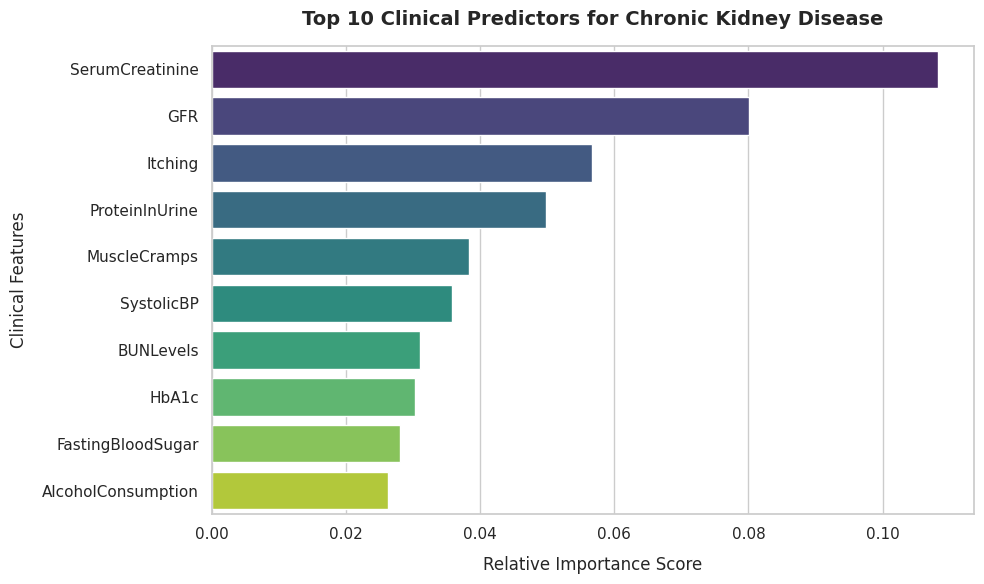

In [9]:
# ==============================================================================
# STEP 9: FEATURE IMPORTANCE VISUALIZATION
# ==============================================================================

# Extract feature importance from the trained Random Forest component
rf_trained = ensemble_model.named_estimators_['random_forest']
importances = rf_trained.feature_importances_
feature_names = X_imputed.columns

# Create a DataFrame for structural mapping
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plotting the Top 10 Clinical Predictors
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Clinical Predictors for Chronic Kidney Disease', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance Score', fontsize=12, labelpad=10)
plt.ylabel('Clinical Features', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()